In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load parquet file
df = pd.read_parquet(
    "../data/processed/uk_energy_master.parquet"
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (444670, 23)


,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,source_file
0,2001-01-01,1,38631,NaN,34060,NaN,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,../data/raw/energy\demanddata_2001.csv
1,2001-01-01,2,39808,NaN,35370,NaN,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,../data/raw/energy\demanddata_2001.csv
2,2001-01-01,3,40039,NaN,35680,NaN,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,../data/raw/energy\demanddata_2001.csv
3,2001-01-01,4,39339,NaN,35029,NaN,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,../data/raw/energy\demanddata_2001.csv
4,2001-01-01,5,38295,NaN,34047,NaN,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,../data/raw/energy\demanddata_2001.csv


In [2]:
print("\nRows and Columns")
print(df.shape)

print("\nColumns")
print(df.columns.tolist())


Rows and Columns
(444670, 23)

Columns
['SETTLEMENT_DATE', 'SETTLEMENT_PERIOD', 'ND', 'TSD', 'ENGLAND_WALES_DEMAND', 'EMBEDDED_WIND_GENERATION', 'EMBEDDED_WIND_CAPACITY', 'EMBEDDED_SOLAR_GENERATION', 'EMBEDDED_SOLAR_CAPACITY', 'NON_BM_STOR', 'PUMP_STORAGE_PUMPING', 'SCOTTISH_TRANSFER', 'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW', 'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW', 'NSL_FLOW', 'ELECLINK_FLOW', 'VIKING_FLOW', 'GREENLINK_FLOW', 'source_file']


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 444670 entries, 0 to 444669
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   SETTLEMENT_DATE            444670 non-null  str    
 1   SETTLEMENT_PERIOD          444670 non-null  int64  
 2   ND                         444670 non-null  int64  
 3   TSD                        374542 non-null  float64
 4   ENGLAND_WALES_DEMAND       444670 non-null  int64  
 5   EMBEDDED_WIND_GENERATION   339502 non-null  float64
 6   EMBEDDED_WIND_CAPACITY     339502 non-null  float64
 7   EMBEDDED_SOLAR_GENERATION  304414 non-null  float64
 8   EMBEDDED_SOLAR_CAPACITY    304414 non-null  float64
 9   NON_BM_STOR                444670 non-null  int64  
 10  PUMP_STORAGE_PUMPING       444670 non-null  int64  
 11  SCOTTISH_TRANSFER          58990 non-null   float64
 12  IFA_FLOW                   444670 non-null  int64  
 13  IFA2_FLOW                  304414 non-nu

In [5]:
df["SETTLEMENT_DATE"] = pd.to_datetime(
    df["SETTLEMENT_DATE"],
    format="mixed",
    dayfirst=True
)

In [7]:
print("Start Date:", df["SETTLEMENT_DATE"].min())
print("End Date:", df["SETTLEMENT_DATE"].max())
print(df["SETTLEMENT_DATE"].isna().sum())

Start Date: 2001-01-01 00:00:00
End Date: 2026-12-05 00:00:00
0


In [8]:
daily_df = (
    df.groupby("SETTLEMENT_DATE")["ND"]
      .mean()
      .reset_index()
)

print(daily_df.shape)

daily_df.head()

(9264, 2)


,SETTLEMENT_DATE,ND
0,2001-01-01,35616.520833
1,2001-01-02,47423.416667
2,2001-01-03,47082.916667
3,2001-01-04,34527.708333
4,2001-01-05,39791.687500


In [9]:
print("Number of Days:", len(daily_df))

Number of Days: 9264


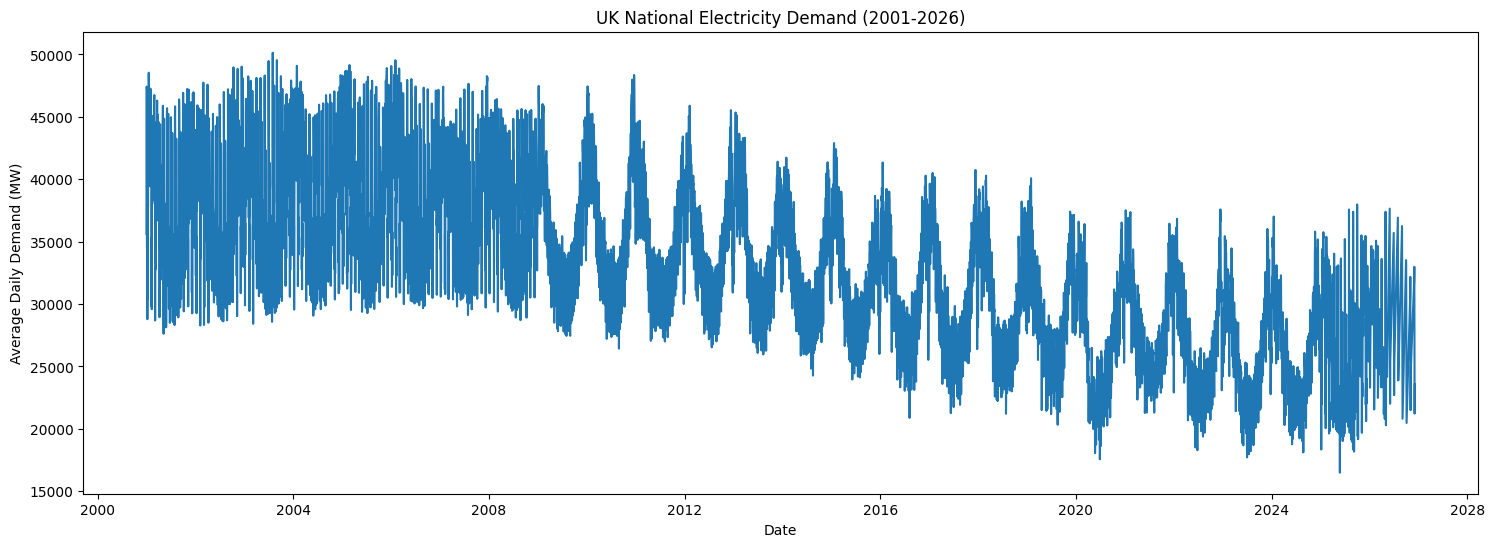

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

plt.plot(
    daily_df["SETTLEMENT_DATE"],
    daily_df["ND"]
)

plt.title(
    "UK National Electricity Demand (2001-2026)"
)

plt.xlabel("Date")
plt.ylabel("Average Daily Demand (MW)")
plt.savefig(
    "../reports/figures/uk_national_electricity_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
daily_df["Year"] = (
    daily_df["SETTLEMENT_DATE"]
    .dt.year
)

yearly = (
    daily_df.groupby("Year")["ND"]
      .mean()
      .reset_index()
)

yearly

,Year,ND
0,2001,38220.500946
1,2002,38045.773783
2,2003,38579.480691
3,2004,39033.159449
4,2005,39104.286502
5,2006,38928.941042
6,2007,38100.703691
7,2008,37787.552115
8,2009,35919.068705
9,2010,36534.827850


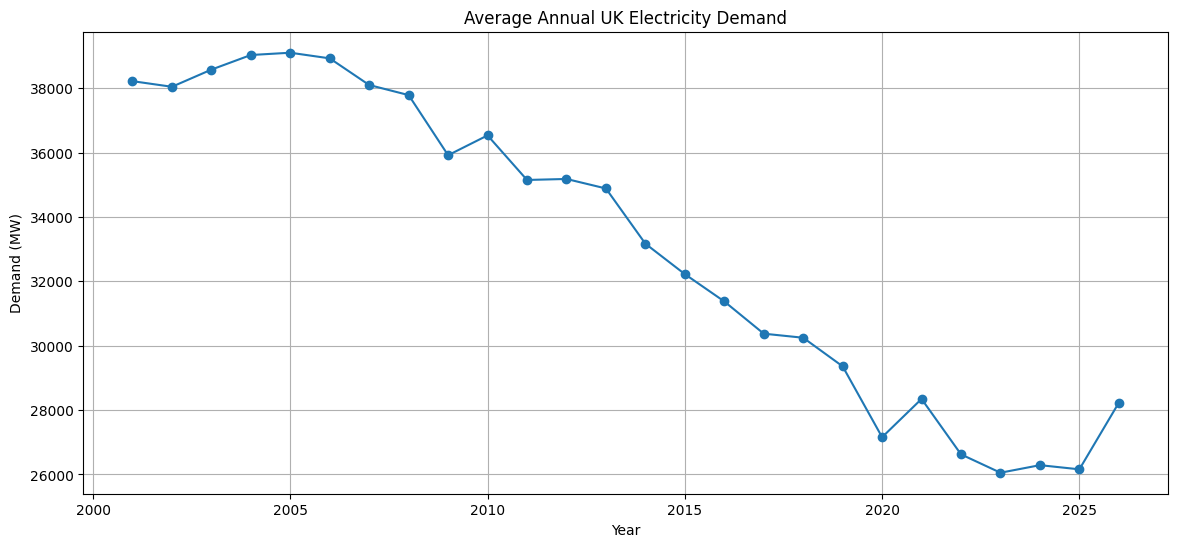

In [12]:
plt.figure(figsize=(14,6))

plt.plot(
    yearly["Year"],
    yearly["ND"],
    marker="o"
)

plt.title(
    "Average Annual UK Electricity Demand"
)

plt.xlabel("Year")
plt.ylabel("Demand (MW)")

plt.grid(True)

plt.show()

In [13]:
highest_year = yearly.loc[
    yearly["ND"].idxmax()
]

lowest_year = yearly.loc[
    yearly["ND"].idxmin()
]

print("Highest Demand Year")
print(highest_year)

print("\nLowest Demand Year")
print(lowest_year)

Highest Demand Year
Year     2005.000000
ND      39104.286502
Name: 4, dtype: float64

Lowest Demand Year
Year     2023.000000
ND      26051.948857
Name: 22, dtype: float64


In [15]:
daily_df["Month"] = (
    daily_df["SETTLEMENT_DATE"]
    .dt.month
)

monthly = (
    daily_df.groupby("Month")["ND"]
      .mean()
      .reset_index()
)

monthly

,Month,ND
0,1,37916.556659
1,2,37134.267996
2,3,35192.669901
3,4,32027.896238
4,5,30511.836774
5,6,30004.206457
6,7,29887.854647
7,8,29693.929380
8,9,31050.159768
9,10,33045.578740


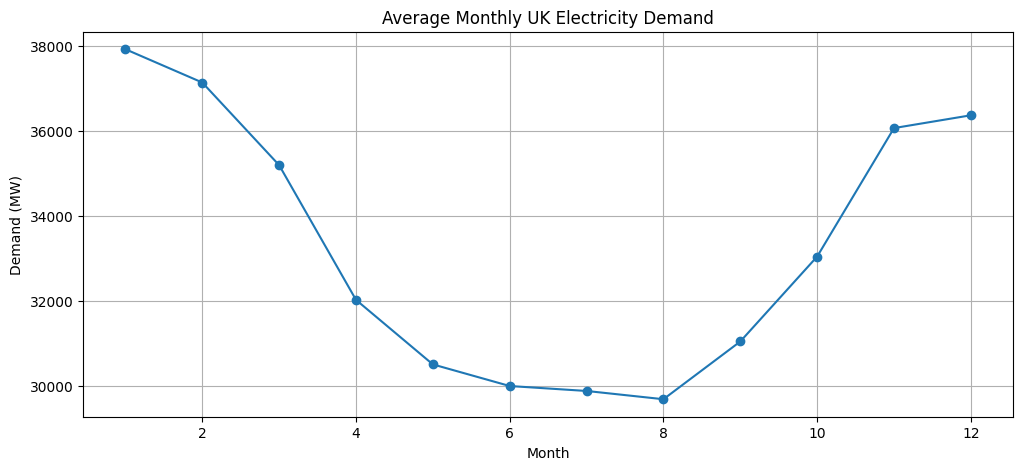

In [16]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly["Month"],
    monthly["ND"],
    marker="o"
)

plt.title(
    "Average Monthly UK Electricity Demand"
)

plt.xlabel("Month")
plt.ylabel("Demand (MW)")

plt.grid(True)

plt.show()

In [17]:
print(daily_df.shape)
print(monthly.head())

(9264, 4)
   Month            ND
0      1  37916.556659
1      2  37134.267996
2      3  35192.669901
3      4  32027.896238
4      5  30511.836774


In [27]:
monthly.loc[monthly["ND"].idxmax()]


Month        1.000000
ND       37916.556659
Name: 0, dtype: float64

In [28]:
monthly.loc[monthly["ND"].idxmin()]

Month        8.00000
ND       29693.92938
Name: 7, dtype: float64

In [24]:
daily_df["Year"] = daily_df["SETTLEMENT_DATE"].dt.year

yearly = (
    daily_df.groupby("Year")["ND"]
    .mean()
    .reset_index()
)

yearly.head()

,Year,ND
0,2001,38220.500946
1,2002,38045.773783
2,2003,38579.480691
3,2004,39033.159449
4,2005,39104.286502


In [25]:
highest_year = yearly.loc[yearly["ND"].idxmax()]
lowest_year = yearly.loc[yearly["ND"].idxmin()]

print(highest_year)
print(lowest_year)

Year     2005.000000
ND      39104.286502
Name: 4, dtype: float64
Year     2023.000000
ND      26051.948857
Name: 22, dtype: float64


In [29]:
import os

os.makedirs("../reports/figures", exist_ok=True)

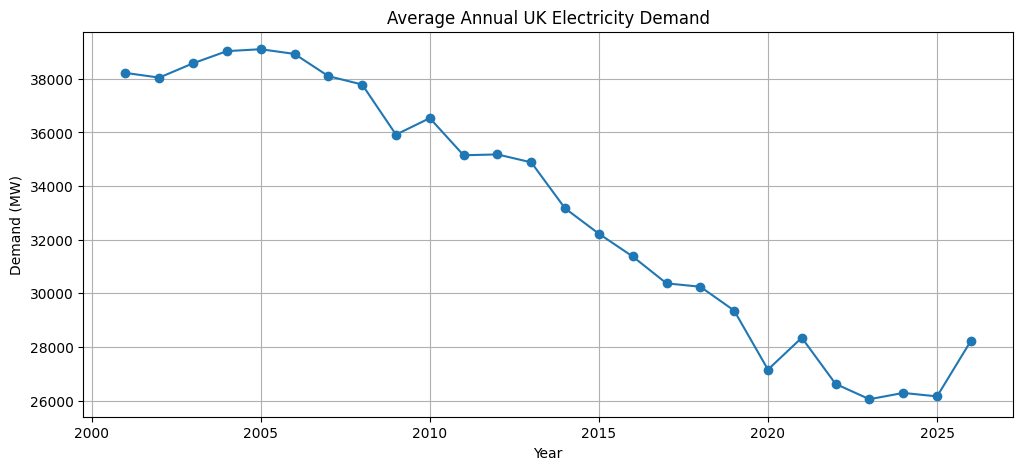

In [30]:
plt.figure(figsize=(12,5))

plt.plot(
    yearly["Year"],
    yearly["ND"],
    marker="o"
)

plt.title("Average Annual UK Electricity Demand")
plt.xlabel("Year")
plt.ylabel("Demand (MW)")
plt.grid(True)

plt.savefig(
    "../reports/figures/annual_demand_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

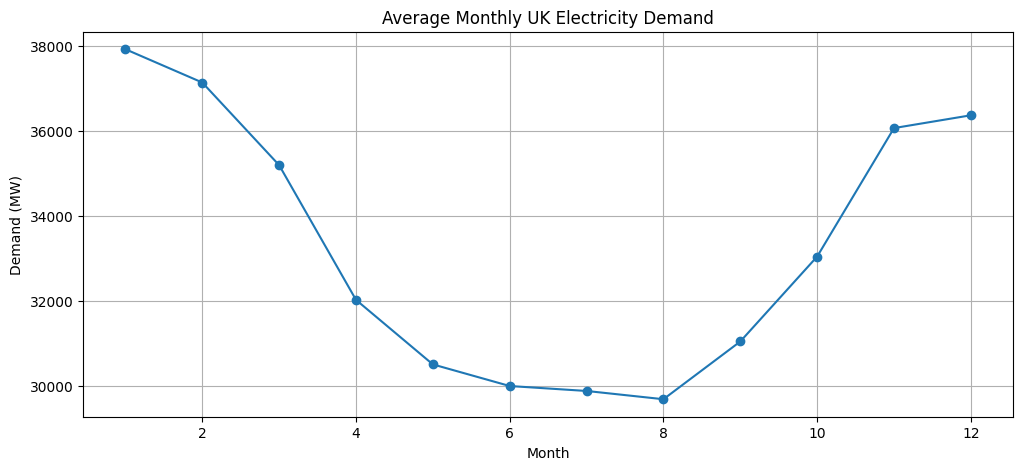

In [31]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly["Month"],
    monthly["ND"],
    marker="o"
)

plt.title("Average Monthly UK Electricity Demand")
plt.xlabel("Month")
plt.ylabel("Demand (MW)")
plt.grid(True)

plt.savefig(
    "../reports/figures/monthly_seasonality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
import os

print(os.listdir("../reports/figures"))

['annual_demand_trend.png', 'monthly_seasonality.png', 'uk_national_electricity_demand.png']


In [35]:
plt.savefig("../reports/figures/chart_name.png", dpi=300)

<Figure size 640x480 with 0 Axes>